### Load packages

In [5]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import textwrap
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
import plotly.graph_objects as go
from plotly.tools import mpl_to_plotly
import plotly.io as pio
# from itertools import combinations



### Define parameters and file info

In [6]:
data_directory = r"..\data\daf_to_daf_network"

# -----------------------------------------------------------------------
# DAF-to-DAF data
# -----------------------------------------------------------------------
daf2daf_csv_file = r"DAF-to-DAF Giving - 2023 $10M+.csv"
daf2daf_path = os.path.join(data_directory, daf2daf_csv_file)
print("DAF-to-DAF CSV file:", daf2daf_path)
if os.path.exists(daf2daf_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# DAF asset data
# -----------------------------------------------------------------------
daf_asset_csv_file = r"DAF Assets - 2023 $10M+.csv"
daf_asset_csv_path = os.path.join(data_directory, daf_asset_csv_file)
print("DAF assets CSV file:", daf_asset_csv_path)
if os.path.exists(daf_asset_csv_path):
    print("EXISTS")

# -----------------------------------------------------------------------
# DAF node ordering data
# -----------------------------------------------------------------------
node_order_csv_file = r"DAF_node_order.csv"
node_order_csv_path = os.path.join(data_directory, node_order_csv_file)
print("DAF node ordering CSV file:", node_order_csv_path)
if os.path.exists(node_order_csv_path):
    print("EXISTS")


DAF-to-DAF CSV file: ..\data\daf_to_daf_network\DAF-to-DAF Giving - 2023 $10M+.csv
EXISTS
DAF assets CSV file: ..\data\daf_to_daf_network\DAF Assets - 2023 $10M+.csv
EXISTS
DAF node ordering CSV file: ..\data\daf_to_daf_network\DAF_node_order.csv
EXISTS


### Load in data

In [7]:
# Load DAF-to-DAF data

raw_df = pd.read_csv(daf2daf_path)

print(raw_df.info())
raw_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order                   86 non-null     int64 
 1   Grantor EIN             86 non-null     object
 2   Grantor Name            86 non-null     object
 3   Clean Grantor Name      86 non-null     object
 4   Recipient EIN           86 non-null     object
 5   Recipient Name          86 non-null     object
 6   Clean Recipient Name    86 non-null     object
 7   Grantor/Recipient Type  86 non-null     object
 8   Cash Grant Amount       86 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 6.2+ KB
None


,Order,Grantor EIN,Grantor Name,Clean Grantor Name,Recipient EIN,Recipient Name,Clean Recipient Name,Grantor/Recipient Type,Cash Grant Amount
0,1,06-1676688,DECHOMAI FOUNDATION INC,Dechomai Foundation,04-6010342,BANK OF AMERICA CHARITABLE GIFT FUND 215-09900...,Bank of America Charitable Gift Fund,Nat-to-Nat,14900294
1,2,06-1676688,DECHOMAI FOUNDATION INC,Dechomai Foundation,11-0303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUND,Fidelity Charitable,Nat-to-Nat,24419423
2,3,06-1676688,DECHOMAI FOUNDATION INC,Dechomai Foundation,23-2888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,Vanguard Charitable,Nat-to-Nat,24897781
3,4,06-1676688,DECHOMAI FOUNDATION INC,Dechomai Foundation,31-1774905,GOLDMAN SACHS PHILANTHROPY FUND,Goldman Sachs Philanthropy Fund,Nat-to-Nat,40272775
4,5,06-1676688,DECHOMAI FOUNDATION INC,Dechomai Foundation,34-1747398,AMERICAN ENDOWMENT FOUNDATION,American Endowment Foundation,Nat-to-Nat,162583020


In [8]:
# Load DAF node ordering data

raw_node_df = pd.read_csv(node_order_csv_path)

# print(raw_node_df.info())
raw_node_df.head()

,Order,EIN,Type,Name,Clean Name
0,6,26-0724604,Other Sponsors,DECHOMAI ASSET TRUST,Dechomai Asset Trust
1,7,06-1676688,Other Sponsors,DECHOMAI FOUNDATION INC,Dechomai Foundation
2,3,34-1747398,Other Sponsors,AMERICAN ENDOWMENT FOUNDATION,American Endowment Foundation
3,4,04-2103559,Other Sponsors,COMBINED JEWISH PHILANTHROPIES OF GREATER BOST...,Combined Jewish Phil. of Greater Boston
4,5,45-4678325,Other Sponsors,BRADLEY IMPACT FUND INC,Bradley Impact Fund


In [9]:
# Clean & format columns in DAF-to-DAF data

node_clean_df = raw_node_df.copy()

node_clean_df["EIN"] = node_clean_df["EIN"].str.replace("-","")
node_clean_df["EIN"] = node_clean_df["EIN"].astype("Int64")

node_clean_df.head()

,Order,EIN,Type,Name,Clean Name
0,6,260724604,Other Sponsors,DECHOMAI ASSET TRUST,Dechomai Asset Trust
1,7,61676688,Other Sponsors,DECHOMAI FOUNDATION INC,Dechomai Foundation
2,3,341747398,Other Sponsors,AMERICAN ENDOWMENT FOUNDATION,American Endowment Foundation
3,4,42103559,Other Sponsors,COMBINED JEWISH PHILANTHROPIES OF GREATER BOST...,Combined Jewish Phil. of Greater Boston
4,5,454678325,Other Sponsors,BRADLEY IMPACT FUND INC,Bradley Impact Fund


In [10]:
# Load DAF asset data

asset_raw_df = pd.read_csv(daf_asset_csv_path)

print(asset_raw_df.info())
asset_raw_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   EIN     42 non-null     int64 
 1   Name    42 non-null     object
 2   Assets  42 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ KB
None


,EIN,Name,Assets
0,205205488,SILICON VALLEY COMMUNITY FOUNDATION,10356051571
1,46010342,BANK OF AMERICA CHARITABLE GIFT FUND 215-09900...,4162617542
2,341747398,AMERICAN ENDOWMENT FOUNDATION,7145882316
3,42103559,COMBINED JEWISH PHILANTHROPIES OF GREATER BOST...,2188177334
4,454678325,BRADLEY IMPACT FUND INC,159276607


In [11]:
# Clean & format columns in asset data

asset_df = asset_raw_df.copy()

asset_df["EIN"] = asset_df["EIN"].astype("Int64")

asset_df.head()

,EIN,Name,Assets
0,205205488,SILICON VALLEY COMMUNITY FOUNDATION,10356051571
1,46010342,BANK OF AMERICA CHARITABLE GIFT FUND 215-09900...,4162617542
2,341747398,AMERICAN ENDOWMENT FOUNDATION,7145882316
3,42103559,COMBINED JEWISH PHILANTHROPIES OF GREATER BOST...,2188177334
4,454678325,BRADLEY IMPACT FUND INC,159276607


In [12]:
# Set ordering and name lookup based on the nodes CSV file

# sort by the order field
node_sorted_df = node_clean_df.sort_values("Order")

# Create mapping of names
name_to_clean = dict(zip(node_sorted_df["Name"], node_sorted_df["Clean Name"]))

In [13]:
# Set color mapping
# Adapted from
# Colorblind-safe VincentvanGogh_1 palette from Regenbogen
# Source: https://github.com/tylerlittlefield/lisa

color_map_dict = {
    "Commercially Affiliated Sponsors": "#D95F30",
    "Community Foundations": "#DABD61",
    "Donation/Workplace Processors": "#6D8325",
    "Other Sponsors": "#8785B2"
}

In [14]:
# Text wrapping function

def wrap_label(s, width):
    return "\n".join(textwrap.wrap(s, width=width))

In [15]:
%matplotlib inline
matplotlib.get_backend()

'inline'

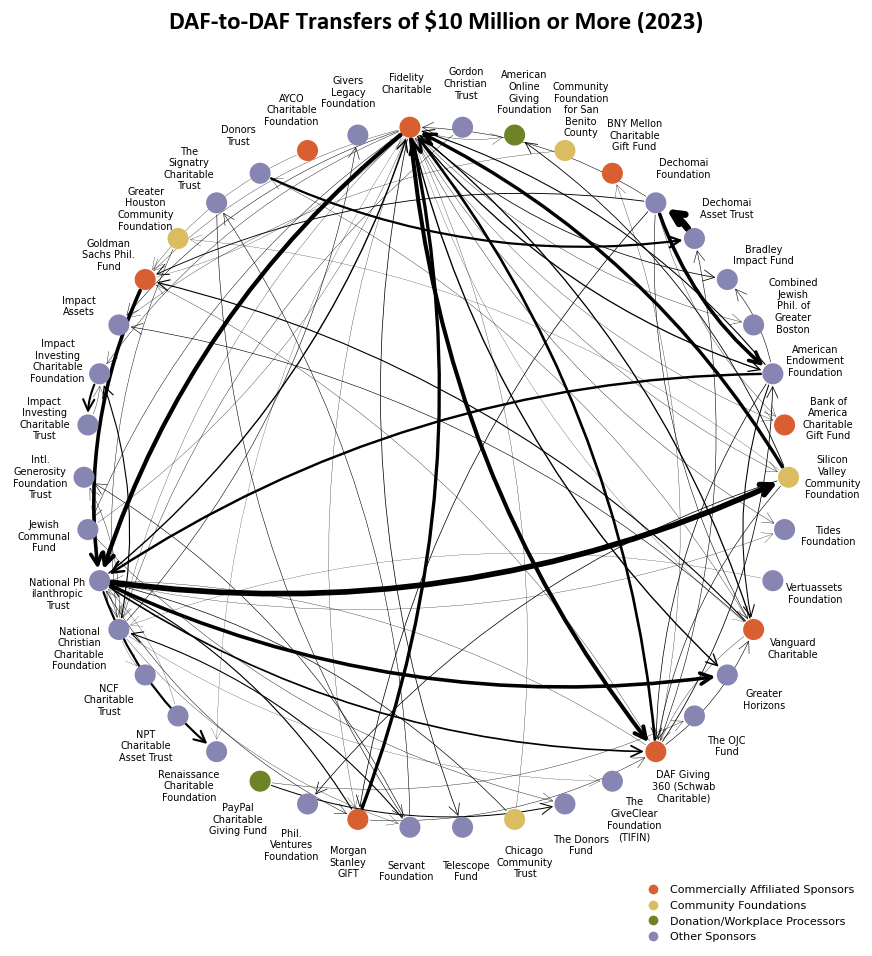

In [16]:
# Arrow plot using networkx

# Set parameters
wrap_width = 11

# Initialize directed graph
G = nx.DiGraph()

# Add nodes in the specific sorted order
for _, row in node_sorted_df.iterrows():
    G.add_node(row["Name"], clean_label=row["Clean Name"])

# Add edges
for _, r in raw_df.iterrows():
    G.add_edge(
        r["Grantor Name"],
        r["Recipient Name"],
        weight=r["Cash Grant Amount"]
    )

# Create label map using the clean name column from nodes dataframe
label_map = {
    n: wrap_label(G.nodes[n].get("clean_label", n), width=wrap_width)
    for n in G.nodes()
}

# Create color mapping using type column from nodes dataframe
node_colors = []
for node in G.nodes():
    node_type = node_sorted_df.loc[node_sorted_df["Name"] == node, "Type"].values[0]
    node_colors.append(color_map_dict.get(node_type, "grey"))

# Set layout
# pos = nx.circular_layout(G)
pos = nx.circular_layout(G, scale=1.2)

# Calculate label position based on the radius plus a given offset from the center
label_pos = {}
for n, (x, y) in pos.items():
    r_distance = (x**2 + y**2) ** 0.5
    offset = 0.15   # controls how far labels sit outside nodes
    label_pos[n] = (
        x * (r_distance + offset) / r_distance,
        y * (r_distance + offset) / r_distance
    )

# scale edge widths
weights = [G[u][v]["weight"] for u, v in G.edges()]
max_weights = max(weights) if weights else 1
edge_widths = [w / max_weights * 5 for w in weights]

plt.figure(figsize=(11, 11))

# Actually draw nodes
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors)

# Draw labels
# nx.draw_networkx_labels(G, pos, font_size=7)
nx.draw_networkx_labels(
    G,
    # pos,
    label_pos,
    labels=label_map,
    font_size=7,
    horizontalalignment="center",
    verticalalignment="center"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=20,
    width=edge_widths,
    connectionstyle="arc3,rad=0.15"
)

# Add a legend
# Create invisible lines with markers to represent the nodes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=node_type,
           markerfacecolor=color, markersize=8) 
    for node_type, color in color_map_dict.items()
]
# Add the legend to the lower left
plt.legend(
    handles=legend_elements, 
    title=None,
    loc='lower left', 
    bbox_to_anchor=(.73, -0.06), 
    fontsize=8,
    frameon=False,
    handletextpad=0.5
)

plt.axis("off")
plt.title("DAF-to-DAF Transfers of $10 Million or More (2023)", 
          fontsize=18, 
          fontweight="bold",
          fontfamily="Calibri",
          y=1.02)

# Save as a PNG
plt.savefig("daf2daf_network.png", dpi=300, bbox_inches='tight', transparent=False, facecolor="white")

# Save as an SVG )
plt.savefig("daf2daf_network.svg", format='svg', bbox_inches='tight', facecolor="white")

plt.show()

### Graph with sized nodes

In [17]:
# Join asset data to graph data

node_assets_df = node_sorted_df.merge(
    asset_raw_df[["EIN", "Assets"]],
    on="EIN",
    how="left"
)

node_assets_df["Assets"] = node_assets_df["Assets"].fillna(0)

node_assets_df["Big Dots"] = (
    (node_assets_df["Assets"].fillna(0) != 0).astype(int)
)

node_assets_df.head()

,Order,EIN,Type,Name,Clean Name,Assets,Big Dots
0,1,205205488,Community Foundations,SILICON VALLEY COMMUNITY FOUNDATION,Silicon Valley Community Foundation,10356051571,1
1,2,46010342,Commercially Affiliated Sponsors,BANK OF AMERICA CHARITABLE GIFT FUND 215-09900...,Bank of America Charitable Gift Fund,4162617542,1
2,3,341747398,Other Sponsors,AMERICAN ENDOWMENT FOUNDATION,American Endowment Foundation,7145882316,1
3,4,42103559,Other Sponsors,COMBINED JEWISH PHILANTHROPIES OF GREATER BOST...,Combined Jewish Phil. of Greater Boston,2188177334,1
4,5,454678325,Other Sponsors,BRADLEY IMPACT FUND INC,Bradley Impact Fund,159276607,1


In [18]:
# Set different possible assets to use

node_assets_df["Assets Logged"] = np.log1p(node_assets_df["Assets"])
node_assets_df["Big Dots x 10"] = (node_assets_df["Big Dots"] + 10) * 10 

assets_to_use = "Assets"
# assets_to_use = "Assets Logged" 
# assets_to_use = "Big Dots" 
# assets_to_use = "Big Dots x 10" 

node_assets_df.head()

,Order,EIN,Type,Name,Clean Name,Assets,Big Dots,Assets Logged,Big Dots x 10
0,1,205205488,Community Foundations,SILICON VALLEY COMMUNITY FOUNDATION,Silicon Valley Community Foundation,10356051571,1,23.060837,110
1,2,46010342,Commercially Affiliated Sponsors,BANK OF AMERICA CHARITABLE GIFT FUND 215-09900...,Bank of America Charitable Gift Fund,4162617542,1,22.149410,110
2,3,341747398,Other Sponsors,AMERICAN ENDOWMENT FOUNDATION,American Endowment Foundation,7145882316,1,22.689802,110
3,4,42103559,Other Sponsors,COMBINED JEWISH PHILANTHROPIES OF GREATER BOST...,Combined Jewish Phil. of Greater Boston,2188177334,1,21.506335,110
4,5,454678325,Other Sponsors,BRADLEY IMPACT FUND INC,Bradley Impact Fund,159276607,1,18.886153,110


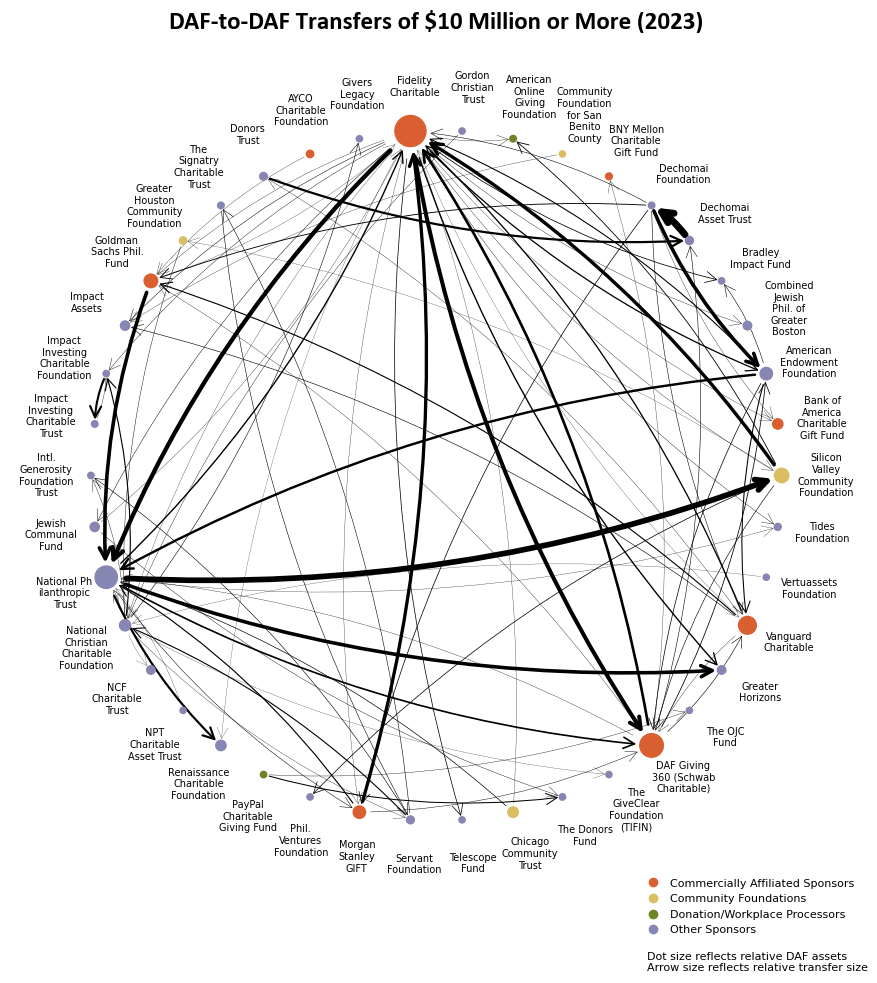

In [19]:
# Arrow plot using networkx with dots sized by assets

# Set parameters
wrap_width = 11

# Node offsets and scaling
min_offset = 0.11
max_offset = 0.155
label_scaling_factor = 0.115
node_start_scaling_factor = 0.9
node_end_scaling_factor = 0.65
base_rad = 0.1
rad_multiplier = 0.0005

# Node size scaling
min_size = 20
max_size = 500
sizes = node_assets_df[assets_to_use]
node_assets_df["Node Size"] = (
    min_size
    + (sizes - sizes.min()) / (sizes.max() - sizes.min())
    * (max_size - min_size)
)

# Initialize directed graph
G = nx.DiGraph()

# Add nodes
for _, row in node_assets_df.iterrows():
    G.add_node(
        row["Name"],
        clean_label=row["Clean Name"],
        node_size=row["Node Size"]
    )

# Add edges
for _, r in raw_df.iterrows():
    G.add_edge(
        r["Grantor Name"],
        r["Recipient Name"],
        weight=r["Cash Grant Amount"]
    )

# Compute dynamic edge curvature
edge_rads = {}
for u, v in G.edges():
    node_u_size = G.nodes[u]["node_size"]
    node_v_size = G.nodes[v]["node_size"]
    edge_rads[(u, v)] = base_rad + rad_multiplier * np.sqrt((node_u_size + node_v_size)/2)

# Create label map
label_map = {
    n: wrap_label(G.nodes[n].get("clean_label", n), width=wrap_width)
    for n in G.nodes()
}

# Create node color mapping
node_colors = []
for node in G.nodes():
    node_type = node_assets_df.loc[node_assets_df["Name"] == node, "Type"].values[0]
    node_colors.append(color_map_dict.get(node_type, "grey"))

# Compute circular layout
pos = nx.circular_layout(G, scale=1.2)

# Shift layout to the right to avoid left-label clipping
x_shift = 0.2
for n in pos:
    pos[n] = (pos[n][0] + x_shift, pos[n][1])

# Precompute label positions based on node radius
label_pos = {}
for n, (x, y) in pos.items():
    r_distance = np.sqrt(x**2 + y**2)
    radius = np.sqrt(G.nodes[n]["node_size"]) * label_scaling_factor
    offset = np.clip(radius, min_offset, max_offset)
    label_pos[n] = (
        x * (r_distance + offset) / r_distance,
        y * (r_distance + offset) / r_distance
    )

# Scale edge widths
weights = [G[u][v]["weight"] for u, v in G.edges()]
max_weights = max(weights) if weights else 1
edge_widths = [w / max_weights * 5 for w in weights]

plt.figure(figsize=(11, 11))

# Explicitly set axes limits so labels are not cut off
all_x = [x for x, y in label_pos.values()] + [x for x, y in pos.values()]
all_y = [y for x, y in label_pos.values()] + [y for x, y in pos.values()]

max_label_len = max(len(lbl) for lbl in label_map.values())
x_left_padding = max_label_len * 0.003   # tweak as needed
x_right_padding = max_label_len * 0.003  # tweak as needed
y_bottom_padding = 0.05
y_top_padding = 0.06

plt.xlim(min(all_x) - x_left_padding, max(all_x) + x_right_padding)
plt.ylim(min(all_y) - y_bottom_padding, max(all_y) + y_top_padding)
plt.axis("off")
# Draw nodes
node_sizes = [G.nodes[n]["node_size"] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)

# Draw labels
nx.draw_networkx_labels(
    G,
    label_pos,
    labels=label_map,
    font_size=7,
    horizontalalignment="center",
    verticalalignment="center"
)

# Draw edges one by one with dynamic curvature
ax = plt.gca()
ax.set_aspect('equal')  # ensures x and y scales are identical

for u, v, w in G.edges(data=True):
    x_start, y_start = pos[u]
    x_end, y_end = pos[v]

    # radius of the target node in data units
    source_radius = np.sqrt(G.nodes[u]['node_size']) * node_start_scaling_factor
    target_radius = np.sqrt(G.nodes[v]['node_size']) * node_end_scaling_factor

    # create arrow patch with shrinkB
    arrow = FancyArrowPatch(
        (x_start, y_start),
        (x_end, y_end),
        arrowstyle='->',      # like '->'
        mutation_scale=20,     # arrowhead size
        linewidth=w['weight'] / max_weights * 5,
        color='black',
        connectionstyle=f"arc3,rad={edge_rads[(u, v)]:.4f}",
        shrinkA=source_radius,
        shrinkB=target_radius   # pull back from target node
    )
    ax.add_patch(arrow)
    
# Add legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=node_type,
           markerfacecolor=color, markersize=8) 
    for node_type, color in color_map_dict.items()
]
plt.legend(
    handles=legend_elements, 
    title=None,
    loc='lower left', 
    bbox_to_anchor=(.73, -0.082), 
    fontsize=8,
    frameon=False,
    handletextpad=0.5
)

# Add left-justified caption beneath the legend
# bbox_to_anchor y-coordinate is -0.06, so subtract ~0.03 to place below
plt.text(
    x=0.704,           # same x as bbox_to_anchor for left alignment
    y=0.061,          # slightly below the legend
    s="Dot size reflects relative DAF assets\nArrow size reflects relative transfer size",  # caption text
    fontsize=8,
    ha='left',        # left-align the text
    va='top',         # align top of text to y-coordinate
    transform=plt.gcf().transFigure  # position in figure coordinates
)

plt.title("DAF-to-DAF Transfers of $10 Million or More (2023)", 
          fontsize=18, 
          fontweight="bold",
          fontfamily="Calibri",
          y=1.04)

# Save outputs
plt.savefig("daf2daf_network_dotsize.png", dpi=300, bbox_inches='tight', transparent=False, facecolor="white")
plt.savefig("daf2daf_network_dotsize.svg", format='svg', bbox_inches='tight', facecolor="white")

plt.show()
